## Experimentos - MLP MNIST

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

np.random.seed(42)

In [19]:
# --- Funções de ativação ---

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

def softmax(z):
    e = np.exp(z - np.max(z, axis=1, keepdims=True))
    return e / np.sum(e, axis=1, keepdims=True)

# --- Loss ---

def cross_entropy(Y_pred, Y_true):
    N = Y_true.shape[0]
    log_p = -np.log(np.clip(Y_pred, 1e-12, 1.0))
    return np.sum(log_p * Y_true) / N

# --- Rede ---

class MLP:
    def __init__(self, layer_sizes, activation='relu'):
        self.activation = activation
        self.params = {}
        self.num_layers = len(layer_sizes) - 1
        for i in range(self.num_layers):
            n_in  = layer_sizes[i]
            n_out = layer_sizes[i + 1]
            self.params[f'W{i}'] = np.random.randn(n_in, n_out) * np.sqrt(2.0 / n_in)
            self.params[f'b{i}'] = np.zeros((1, n_out))

    def forward(self, X):
        self.cache = {'A0': X}
        for i in range(self.num_layers):
            A_prev = self.cache[f'A{i}']
            Z = A_prev @ self.params[f'W{i}'] + self.params[f'b{i}']
            if i == self.num_layers - 1:
                A = softmax(Z)
            elif self.activation == 'relu':
                A = relu(Z)
            else:
                A = sigmoid(Z)
            self.cache[f'Z{i}'] = Z
            self.cache[f'A{i + 1}'] = A
        return self.cache[f'A{self.num_layers}']

    def loss(self, Y_pred, Y_true):
        return cross_entropy(Y_pred, Y_true)

    def accuracy(self, Y_pred, Y_true):
        return np.mean(np.argmax(Y_pred, axis=1) == np.argmax(Y_true, axis=1))

    def backward(self, Y_true):
        N = Y_true.shape[0]
        self.grads = {}
        dA = (self.cache[f'A{self.num_layers}'] - Y_true) / N
        for i in reversed(range(self.num_layers)):
            A_prev = self.cache[f'A{i}']
            Z      = self.cache[f'Z{i}']
            if i == self.num_layers - 1:
                dZ = dA
            elif self.activation == 'relu':
                dZ = dA * relu_deriv(Z)
            else:
                dZ = dA * sigmoid_deriv(Z)
            self.grads[f'dW{i}'] = A_prev.T @ dZ
            self.grads[f'db{i}'] = np.sum(dZ, axis=0, keepdims=True)
            dA = dZ @ self.params[f'W{i}'].T

    def update(self, lr):
        for i in range(self.num_layers):
            self.params[f'W{i}'] -= lr * self.grads[f'dW{i}']
            self.params[f'b{i}'] -= lr * self.grads[f'db{i}']

### Dados

In [20]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 784).astype(float) / 255
X_test  = X_test.reshape(-1, 784).astype(float)  / 255

def one_hot(y, n=10):
    oh = np.zeros((len(y), n))
    oh[np.arange(len(y)), y] = 1
    return oh

Y_train = one_hot(y_train)
Y_test  = one_hot(y_test)
print(f'Treino: {X_train.shape}  Teste: {X_test.shape}')

Treino: (60000, 784)  Teste: (10000, 784)


### Treinamento

In [21]:
def train(model, X_train, Y_train, X_val, Y_val, epochs=20, lr=0.1, batch_size=256):
    history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}
    N = X_train.shape[0]
    for epoch in range(epochs):
        idx = np.random.permutation(N)
        X_sh, Y_sh = X_train[idx], Y_train[idx]
        for start in range(0, N, batch_size):
            Xb = X_sh[start:start + batch_size]
            Yb = Y_sh[start:start + batch_size]
            model.forward(Xb)
            model.backward(Yb)
            model.update(lr)
        eval_idx = np.random.choice(N, 8000, replace=False)
        train_pred = model.forward(X_train[eval_idx])
        val_pred   = model.forward(X_val)
        history['loss'].append(model.loss(train_pred, Y_train[eval_idx]))
        history['acc'].append(model.accuracy(train_pred, Y_train[eval_idx]))
        history['val_loss'].append(model.loss(val_pred, Y_val))
        history['val_acc'].append(model.accuracy(val_pred, Y_val))
        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d} | loss: {history["loss"][-1]:.4f} | val_acc: {history["val_acc"][-1]*100:.2f}%')
    return history

## Experimentos

In [22]:
np.random.seed(42)
model_A = MLP([784, 64, 32, 10], activation='relu')
print('Config A — [784, 64, 32, 10] + ReLU')
hist_A = train(model_A, X_train, Y_train, X_test, Y_test)

np.random.seed(42)
model_B = MLP([784, 64, 32, 10], activation='sigmoid')
print('\nConfig B — [784, 64, 32, 10] + Sigmoid')
hist_B = train(model_B, X_train, Y_train, X_test, Y_test)

print('\n' + '='*55)
print(f'{"Configuração":<35} {"Acurácia Teste":>15}')
print('='*55)
print(f'{"A — ReLU":<35} {hist_A["val_acc"][-1]*100:>14.2f}%')
print(f'{"B — Sigmoid":<35} {hist_B["val_acc"][-1]*100:>14.2f}%')

Config A — [784, 64, 32, 10] + ReLU
Epoch   5 | loss: 0.1743 | val_acc: 94.94%
Epoch  10 | loss: 0.1239 | val_acc: 95.62%
Epoch  15 | loss: 0.0821 | val_acc: 96.79%
Epoch  20 | loss: 0.0627 | val_acc: 97.02%

Config B — [784, 64, 32, 10] + Sigmoid
Epoch   5 | loss: 0.5140 | val_acc: 87.45%
Epoch  10 | loss: 0.3450 | val_acc: 90.46%
Epoch  15 | loss: 0.2929 | val_acc: 91.82%
Epoch  20 | loss: 0.2659 | val_acc: 92.64%

Configuração                         Acurácia Teste
A — ReLU                                     97.02%
B — Sigmoid                                  92.64%


## Resultados

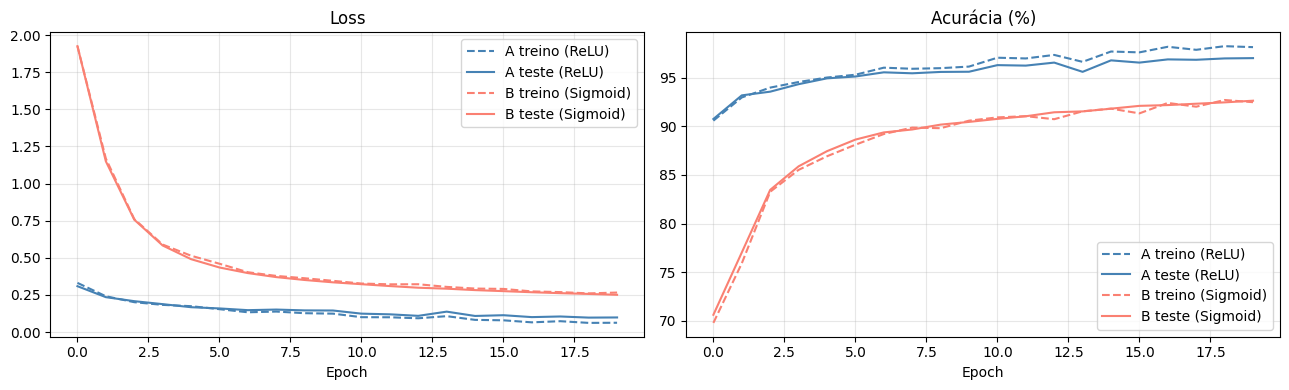

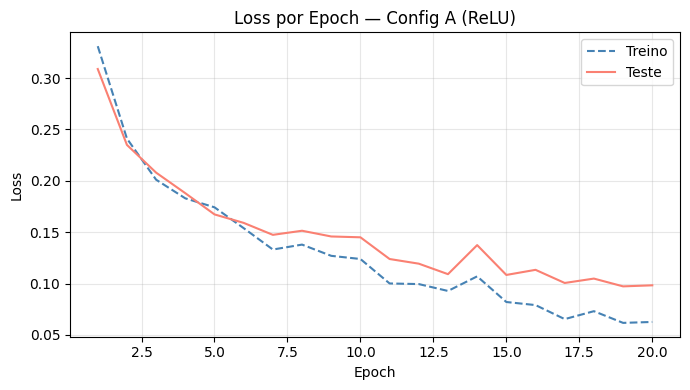

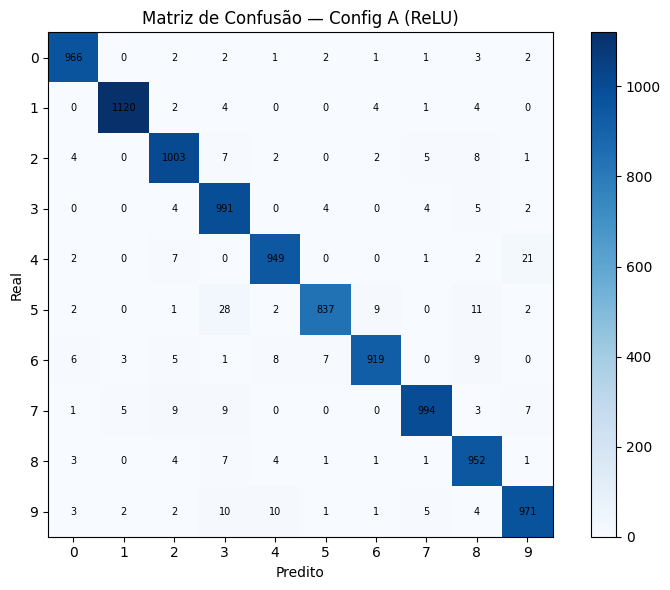

In [23]:
import os

# curvas de loss e acurácia
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_A['loss'],     '--', color='steelblue', label='A treino (ReLU)')
axes[0].plot(hist_A['val_loss'],       color='steelblue', label='A teste (ReLU)')
axes[0].plot(hist_B['loss'],     '--', color='salmon',    label='B treino (Sigmoid)')
axes[0].plot(hist_B['val_loss'],       color='salmon',    label='B teste (Sigmoid)')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot([a*100 for a in hist_A['acc']],     '--', color='steelblue', label='A treino (ReLU)')
axes[1].plot([a*100 for a in hist_A['val_acc']],       color='steelblue', label='A teste (ReLU)')
axes[1].plot([a*100 for a in hist_B['acc']],     '--', color='salmon',    label='B treino (Sigmoid)')
axes[1].plot([a*100 for a in hist_B['val_acc']],       color='salmon',    label='B teste (Sigmoid)')
axes[1].set_title('Acurácia (%)'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# curva de loss treino vs teste (Config A)
epochs_range = range(1, len(hist_A['loss']) + 1)
plt.figure(figsize=(7, 4))
plt.plot(epochs_range, hist_A['loss'],     '--', color='steelblue', label='Treino')
plt.plot(epochs_range, hist_A['val_loss'],       color='salmon',    label='Teste')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Loss por Epoch — Config A (ReLU)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

# matriz de confusão (Config A — melhor modelo)
test_pred   = model_A.forward(X_test)
pred_labels = np.argmax(test_pred, axis=1)
true_labels = np.argmax(Y_test,    axis=1)
cm = np.zeros((10, 10), dtype=int)
for t, p in zip(true_labels, pred_labels):
    cm[t, p] += 1
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=7)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Config A (ReLU)')
plt.tight_layout()
plt.show()